# Unified RS-FFF checkpoint diagnostics

This notebook evaluates a staged unified checkpoint. Change `CHECKPOINT` in the setup cell to
regenerate every plot for another run. The default target is the joint `full` stage in
`checkpoints/water_staged_full`, where polarization and charge transfer are fitted as a single
**induction** channel against `eda_pol + eda_ct`.

The figures cover:

- correlation plots for each fitted energy component, monomer deformation energy, and total
  binding energy
- the per-fragment one-body residual, which is where the size-dependent offset in the
  deformation and binding panels actually lives
- the classical/neural split of every component: how much of each channel is the force field
  and how much is the correction trunk -- and, for induction, how much of the correction is
  the bare `h_frag -> h_env` descriptor swap rather than a relaxation
- molecular polarizability, dipole, and quadrupole moment correlations on the monomer anchor
- predicted atom/pair parameter distributions, one figure per element
- predicted many-body contributions for each energy term
- force correlation for the total-energy gradient


In [ ]:
%matplotlib inline

import os
import sys
from pathlib import Path
from types import SimpleNamespace

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from rsfff.ff.many_body import mbe_dataset
from rsfff.ff.molecular_multipoles import fragment_multipoles, reference_multipoles
from rsfff.ff.multipole import spherical_to_cartesian_quadrupole
from rsfff.ff.units import BOHR_ANG, KJMOL_PER_HARTREE
from rsfff.mlip.reference_states import AtomicStateReference
from rsfff.train.config import load_config, stage_config
from rsfff.train.data import load_datasets, load_extxyz, load_reference_energies
from rsfff.train.loss import compute_forces
from rsfff.train.train_eem import resolve_device
from rsfff.train.train_unified import build_unified_model

In [ ]:
# ---- Regeneration knobs ---------------------------------------------------------------
CHECKPOINT = "checkpoints/water_staged/best.pt"
CONFIG = "configs/water_staged.yaml"
STAGE = "auto"                  # "auto", "frozen", "full", or None
DEVICE = "cpu"                  # CPU is stable for float64 plots; use "auto" if desired.
EVAL_SPLIT = "all"              # "all" or "validation"; validation is per-file here.
MAX_FRAMES_PER_CLUSTER = None    # e.g. 200 for quick iteration
BATCH_SIZE = 64
FORCE_FRAMES_PER_CLUSTER = 40    # forces need autograd; keep this modest for interactivity.
PARAMETER_FRAMES_PER_CLUSTER = 120
MBE_PER_CLUSTER = 40             # strongest frames per w3/w4/w5 cluster for MBE plots.
MBE_SORT_KEY = "int"
ISOLATED_SPECIES_REFERENCE = "data/isolated_species_wb97mv.extxyz"
REFERENCE_SPECIES = "H2O"
FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
# Figure names follow the checkpoint directory, so re-running this on another stage
# writes beside the old figures instead of over them.
FIGPREFIX = Path(CHECKPOINT).parent.name

# (channel, eda components summed to make its label, plot title). The label is a *tuple*
# because `induction` is fitted against `eda_pol + eda_ct` -- polarization and charge transfer
# are one term now, so no single `eda_*` column supervises it. `_TARGETS` and
# `_INDUCTION_COMPONENTS` in rsfff.train.train_unified are what this mirrors.
ENERGY_TERMS = [
    ("onebody", ("fragment_energy",), "monomer deformation energy"),
    ("elst", ("cls_elec",), "frozen electrostatics"),
    ("pauli", ("mod_pauli",), "Pauli repulsion"),
    ("disp", ("disp",), "dispersion"),
    ("induction", ("pol", "ct"), "induction (pol + CT)"),
    ("total", ("energy",), "binding energy"),
]

PALETTE = {
    "w2": "#276ef1",
    "w3": "#1b998b",
    "w4": "#db6d00",
    "w5": "#7a4cc2",
}
ELEMENT = {1: "H", 8: "O"}
ELEMENT_COLOR = {1: "#276ef1", 8: "#d64545"}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})

In [ ]:
def torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def infer_stage_name(checkpoint, cfg):
    if STAGE not in ("auto", None):
        return STAGE
    if STAGE is None or not cfg.stages:
        return None
    run_dir = Path(checkpoint).parent.name
    prefix = f"{cfg.run_name}_"
    if run_dir.startswith(prefix):
        candidate = run_dir[len(prefix):]
        if candidate in {s.name for s in cfg.stages}:
            return candidate
    return cfg.stages[-1].name


def staged_config_for_checkpoint(config_path, checkpoint):
    cfg = load_config(config_path)
    name = infer_stage_name(checkpoint, cfg)
    if name is None:
        return cfg, None
    matches = [s for s in cfg.stages if s.name == name]
    if not matches:
        raise ValueError(f"stage {name!r} is not in {config_path}; available {[s.name for s in cfg.stages]}")
    return stage_config(cfg, matches[0]), name


def load_unified_checkpoint(checkpoint=CHECKPOINT, config=CONFIG, device=DEVICE):
    cfg, stage_name = staged_config_for_checkpoint(config, checkpoint)
    torch.set_default_dtype(torch.float64 if cfg.dtype == "float64" else torch.float32)
    state = torch_load(checkpoint)
    neighbor_types = state.get("neighbor_types")
    if neighbor_types is None:
        probe = load_datasets(cfg.data.path, dtype=torch.get_default_dtype())
        neighbor_types = probe.unique_atomic_numbers
    reference_energies = load_reference_energies(cfg.data.reference_energies, neighbor_types).to(torch.get_default_dtype())
    atomic_states = None
    if cfg.data.atomic_reference_states:
        atomic_states = AtomicStateReference.from_json(
            cfg.data.atomic_reference_states,
            neighbor_types,
            dtype=torch.get_default_dtype(),
        )
    model = build_unified_model(cfg, neighbor_types, reference_energies, atomic_states)
    model.load_state_dict(state["model_state"])
    model.eval()
    resolved = torch.device("cpu" if device == "cpu" else resolve_device(device, cfg.dtype))
    model.to(resolved)
    return model, cfg, state, stage_name, resolved


def cluster_tag(path):
    name = Path(path).name
    for token in name.replace("-", "_").split("_"):
        if token.startswith("w") and token[1:].isdigit():
            return token
    return Path(path).stem


def load_cluster_datasets(cfg):
    paths = cfg.data.path if isinstance(cfg.data.path, list) else [cfg.data.path]
    dtype = torch.float64 if cfg.dtype == "float64" else torch.float32
    return {cluster_tag(p): load_extxyz(p, dtype=dtype) for p in paths}


def reference_species_energy(path=ISOLATED_SPECIES_REFERENCE, species=REFERENCE_SPECIES):
    from ase.io import iread

    for atoms in iread(str(path), index=":"):
        if atoms.info.get("name") == species:
            return float(atoms.get_potential_energy())
    raise ValueError(f"no frame named {species!r} in {path}")


def frame_indices(dataset, cfg):
    n = len(dataset)
    idx = np.arange(n)
    if EVAL_SPLIT == "validation":
        rng = np.random.default_rng(cfg.data.seed)
        perm = rng.permutation(n)
        n_val = max(1, int(round(n * cfg.data.holdout_fraction)))
        idx = np.sort(perm[:n_val])
    elif EVAL_SPLIT != "all":
        raise ValueError("EVAL_SPLIT must be 'all' or 'validation'")
    if MAX_FRAMES_PER_CLUSTER is not None:
        idx = idx[:MAX_FRAMES_PER_CLUSTER]
    return idx.tolist()


def to_np(x):
    return x.detach().cpu().numpy()


def fragment_to_system(batch):
    if batch.fragment_to_batch is not None:
        return batch.fragment_to_batch
    f2b = batch.batch_idx.new_zeros(batch.n_fragments)
    return f2b.scatter_(0, batch.fragment_idx, batch.batch_idx)


def pool_fragments_to_frames(values, batch):
    f2b = fragment_to_system(batch)
    return values.new_zeros(batch.n_systems).index_add_(0, f2b, values)

In [ ]:
model, cfg, state, stage_name, device = load_unified_checkpoint()
datasets = load_cluster_datasets(cfg)
anchor = load_extxyz(cfg.data.monomer_path, dtype=torch.get_default_dtype()) if cfg.data.monomer_path else None
h2o_reference_energy = reference_species_energy()

print(f"checkpoint: {CHECKPOINT}")
print(f"stage: {stage_name or 'single'}")
print(f"epoch: {state.get('epoch', 'unknown')}    val_loss: {state.get('val_loss', float('nan')):.6g}")
print(f"device: {device}    dtype: {cfg.dtype}")
print(f"{REFERENCE_SPECIES} reference: {h2o_reference_energy:.12f} Ha from {ISOLATED_SPECIES_REFERENCE}")
print("datasets:", {tag: len(ds) for tag, ds in datasets.items()})
if anchor is not None:
    print(f"monomer anchor: {len(anchor)} frames from {cfg.data.monomer_path}")

RuntimeError: Error(s) in loading state_dict for UnifiedPairModel:
	Unexpected key(s) in state_dict: "atomic_energy.species_offset". 

In [ ]:
def fragments_per_frame(batch):
    f2b = fragment_to_system(batch)
    return torch.bincount(f2b, minlength=batch.n_systems).to(batch.positions.dtype)


def collect_energy_predictions(model, datasets, cfg, device, monomer_ref_energy, batch_size=BATCH_SIZE):
    rows = {term: {"ref": [], "pred": [], "tag": []} for term, _, _ in ENERGY_TERMS}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)

            for term, target, _label in ENERGY_TERMS:
                if term == "total":
                    n_frag = fragments_per_frame(batch)
                    pred = out.energy - monomer_ref_energy * n_frag
                    ref = batch.energy - monomer_ref_energy * n_frag
                elif term == "onebody":
                    if batch.fragment_energy is None:
                        continue
                    pred = pool_fragments_to_frames(out.fragment_energy - monomer_ref_energy, batch)
                    ref = pool_fragments_to_frames(batch.fragment_energy - monomer_ref_energy, batch)
                else:
                    # `target` is a tuple: induction's label is the sum of two EDA columns.
                    # Skip the channel unless the model has it *and* every component of its
                    # label is on the batch -- a frozen-stage checkpoint has no `induction`
                    # in `out.interaction`, which is what drops the panel rather than an error.
                    if term not in out.interaction or batch.eda is None:
                        continue
                    if any(k not in batch.eda for k in target):
                        continue
                    pred = out.interaction[term]
                    ref = sum(batch.eda[k] for k in target)
                rows[term]["pred"].append(to_np(pred) * KJMOL_PER_HARTREE)
                rows[term]["ref"].append(to_np(ref) * KJMOL_PER_HARTREE)
                rows[term]["tag"].extend([tag] * len(pred))
    packed = {}
    for term, data in rows.items():
        if data["pred"]:
            packed[term] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "tag": np.asarray(data["tag"]),
            }
    return packed


def metrics(ref, pred):
    err = pred - ref
    if len(ref) > 1 and np.std(ref) > 0 and np.std(pred) > 0:
        r2 = float(np.corrcoef(ref, pred)[0, 1] ** 2)
    else:
        r2 = np.nan
    return float(np.abs(err).mean()), float(np.sqrt(np.mean(err ** 2))), r2


energy = collect_energy_predictions(model, datasets, cfg, device, h2o_reference_energy)
print(f"{'term':<12}{'n':>8}{'MAE':>12}{'RMSE':>12}{'R2':>10}")
for term, _target, label in ENERGY_TERMS:
    if term not in energy:
        continue
    mae, rmse, r2 = metrics(energy[term]["ref"], energy[term]["pred"])
    print(f"{term:<12}{len(energy[term]['ref']):>8}{mae:>12.4f}{rmse:>12.4f}{r2:>10.5f}  {label}")

term               n         MAE        RMSE        R2
onebody         9579     17.9629     18.8620   0.66027  monomer deformation energy
elst            9579      0.9188      1.3484   0.99943  frozen electrostatics
pauli           9579      0.5316      0.7276   0.99992  Pauli repulsion
disp            9579      0.2372      0.2877   0.99965  dispersion
induction       9579      0.8103      1.0775   0.99822  induction (pol + CT)
total           9579     17.3819     18.3014   0.97350  binding energy


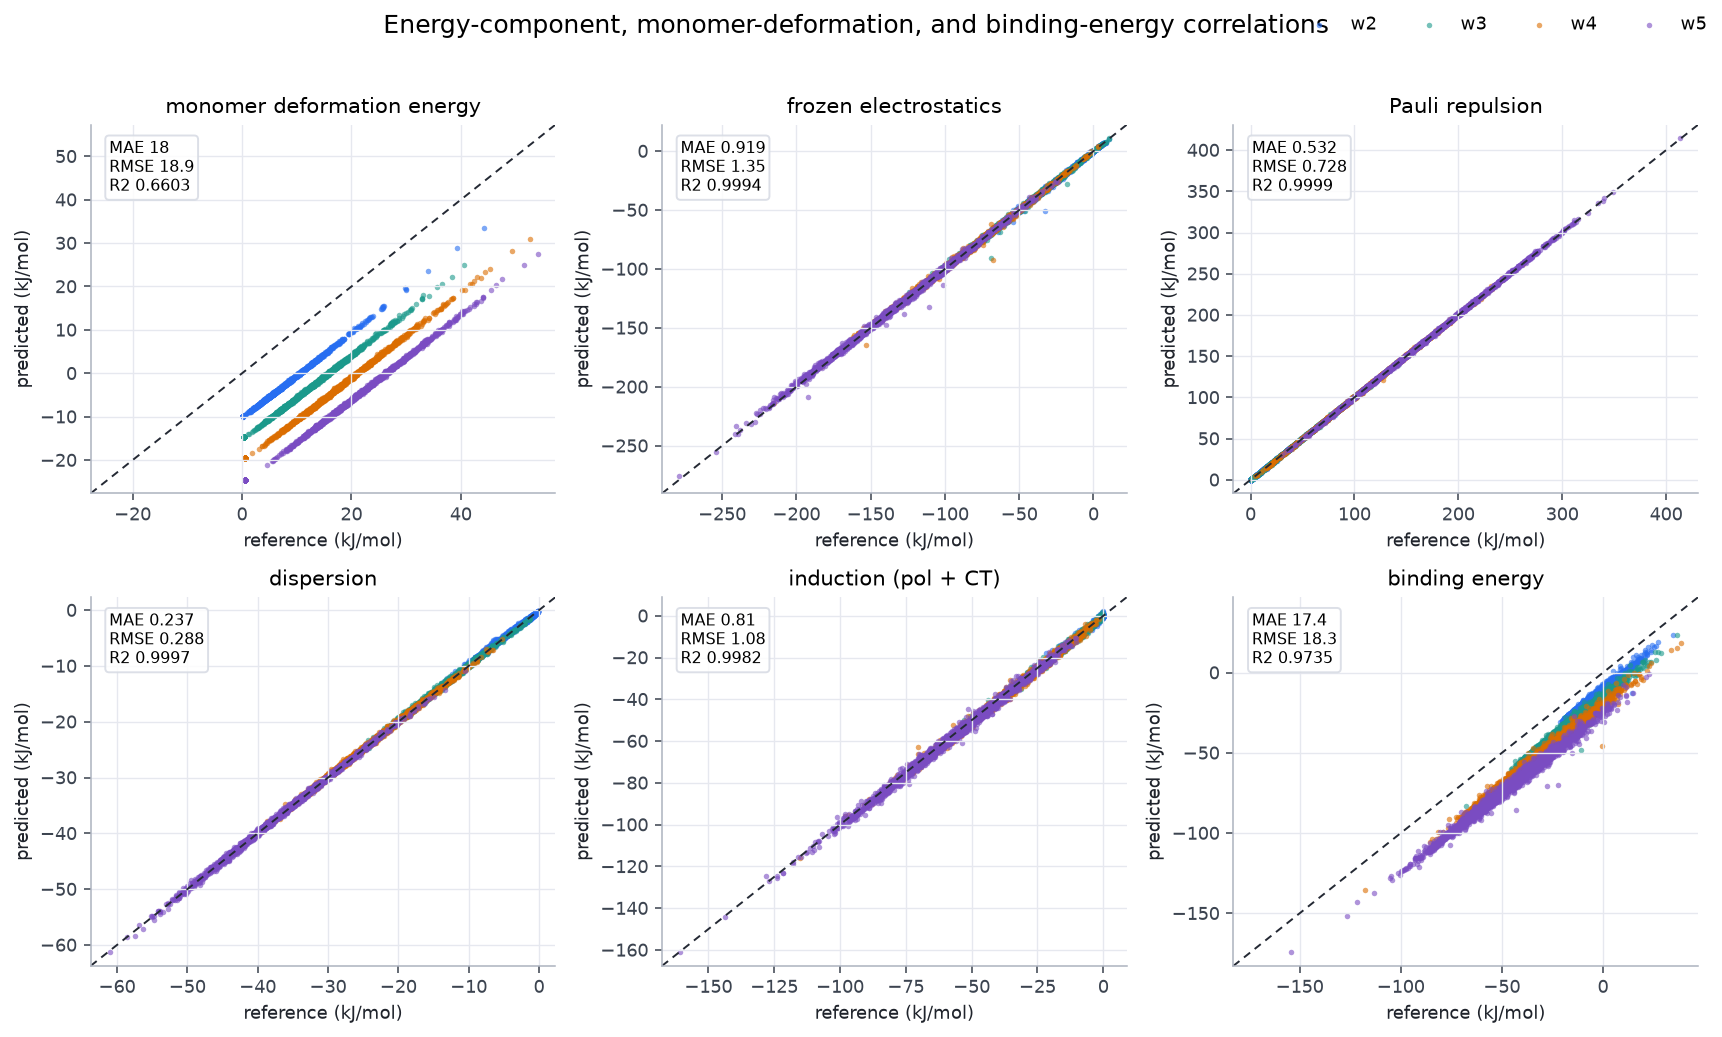

In [ ]:
def plot_parity_grid(data, labels, *, title, unit, path=None, ncols=3):
    keys = [k for k, _ in labels if k in data]
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.1 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, key in zip(axes.ravel(), keys):
        ax.set_visible(True)
        d = data[key]
        ref, pred, tags = d["ref"], d["pred"], d.get("tag")
        lo = min(np.min(ref), np.min(pred))
        hi = max(np.max(ref), np.max(pred))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0, ls=(0, (4, 3)))
        if tags is None:
            ax.scatter(ref, pred, s=8, alpha=0.65, lw=0, color="#276ef1")
        else:
            for tag in sorted(set(tags)):
                m = tags == tag
                ax.scatter(ref[m], pred[m], s=8, alpha=0.6, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(dict(labels)[key])
        ax.set_xlabel(f"reference ({unit})")
        ax.set_ylabel(f"predicted ({unit})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
    handles, labels_ = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="upper right", frameon=False, ncol=len(handles))
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

energy_labels = [(term, label) for term, _target, label in ENERGY_TERMS]
fig = plot_parity_grid(
    energy,
    energy_labels,
    title="Energy-component, monomer-deformation, and binding-energy correlations",
    unit="kJ/mol",
    path=FIGDIR / f"{FIGPREFIX}_energy_correlations.png",
)
plt.show()

## Where the size-dependent offset comes from

The deformation-energy and binding-energy panels above are pooled **per frame**, so a
constant per-*fragment* error is drawn as `n_fragments` times itself: a pure constant looks
like a size-dependent offset. This section separates the two. It reports the one-body
residual per fragment, which is where the constant actually lives, and then replots the two
pooled panels with that single number removed.

Read it as: `bias` is the constant, `MAE - |bias|` is the geometry-dependent part that the
model genuinely gets wrong, and `n_frag * bias` is the offset the pooled plots show.

In [ ]:
def onebody_residual_by_fragment(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-fragment `fragment_energy` residual, kept per fragment rather than per frame.

    `collect_energy_predictions` pools fragments to frames because that is the scale the
    binding energy lives on. That pooling is also what turns a constant into a slope, so this
    deliberately does not do it -- the per-fragment residual is the quantity a constant offset
    is constant in.
    """
    rows = {}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        err, n_frag = [], []
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            e = (out.fragment_energy - batch.fragment_energy) * KJMOL_PER_HARTREE
            err.append(to_np(e))
            n_frag.append(to_np(fragments_per_frame(batch)))
        rows[tag] = {"err": np.concatenate(err), "n_frag": np.concatenate(n_frag)}
    return rows


onebody_res = onebody_residual_by_fragment(model, datasets, cfg, device)
pooled = np.concatenate([d["err"] for d in onebody_res.values()])
BIAS = float(pooled.mean())

print("per-fragment one-body residual (kJ/mol)")
print(f"{'cluster':>8}{'n_frag':>8}{'bias':>10}{'MAE':>10}{'std':>10}{'frame offset':>14}")
for tag in sorted(onebody_res):
    d = onebody_res[tag]
    e, nf = d["err"], float(d["n_frag"][0])
    print(f"{tag:>8}{nf:>8.0f}{e.mean():>+10.4f}{np.abs(e).mean():>10.4f}"
          f"{e.std():>10.4f}{nf * e.mean():>+14.4f}")
print(f"\npooled over {len(pooled)} fragments: bias {BIAS:+.4f}  "
      f"MAE {np.abs(pooled).mean():.4f}  std {pooled.std():.4f}")
print(f"with the constant removed:      MAE {np.abs(pooled - BIAS).mean():.4f}  "
      f"RMSE {np.sqrt(((pooled - BIAS) ** 2).mean()):.4f}")

per-fragment one-body residual (kJ/mol)
 cluster  n_frag      bias       MAE       std  frame offset
      w2       2   -5.1325    5.1325    0.1356      -10.2651
      w3       3   -5.1336    5.1336    0.1356      -15.4009
      w4       4   -5.1330    5.1330    0.1355      -20.5320
      w5       5   -5.1326    5.1326    0.1353      -25.6631

pooled over 33522 fragments: bias -5.1329  MAE 5.1329  std 0.1355
with the constant removed:      MAE 0.1162  RMSE 0.1355


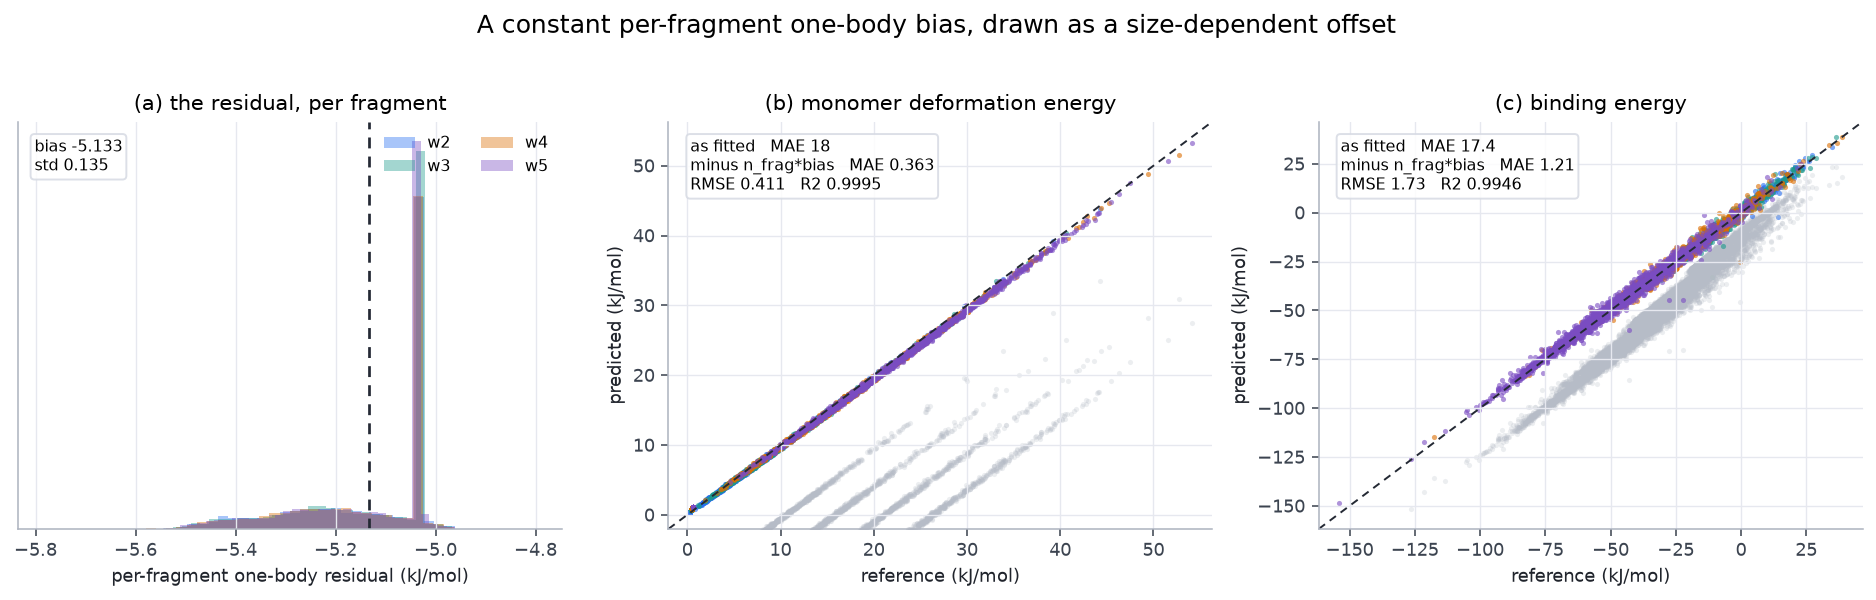

In [ ]:
def plot_onebody_offset(onebody_res, energy, bias, path=None):
    """Left: the residual is a constant. Right/centre: the pooled panels with it removed."""
    tags = sorted(onebody_res)
    per_tag_n_frag = {t: float(onebody_res[t]["n_frag"][0]) for t in tags}
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1))

    ax = axes[0]
    for tag in tags:
        e = onebody_res[tag]["err"]
        ax.hist(e, bins=40, density=True, histtype="stepfilled", alpha=0.4,
                color=PALETTE.get(tag, "#555"), label=tag)
    ax.axvline(bias, color="#242934", lw=1.4, ls=(0, (4, 3)))
    # In axes coordinates, not at the line: the distribution is sharply peaked right where the
    # line falls, so anchoring the label to the data would drop it on top of the spike.
    ax.text(0.03, 0.96, f"bias {bias:+.3f}\nstd {np.concatenate([onebody_res[t]['err'] for t in tags]).std():.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("per-fragment one-body residual (kJ/mol)")
    ax.set_yticks([])
    ax.set_title("(a) the residual, per fragment")
    ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")

    # The pooled panels, before and after removing n_frag * bias. `energy` was collected with
    # the same frame ordering, so `n_frag` lines up term by term.
    for ax, term, label in ((axes[1], "onebody", "monomer deformation energy"),
                            (axes[2], "total", "binding energy")):
        if term not in energy:
            ax.set_visible(False)
            continue
        d = energy[term]
        ref, pred, tag_arr = d["ref"], d["pred"], d["tag"]
        # Fragment count per frame, looked up by cluster tag rather than by position, so this
        # does not depend on the two collectors having iterated the datasets in the same order.
        n_frag = np.array([per_tag_n_frag[t] for t in tag_arr])
        corrected = pred - n_frag * bias
        lo = min(ref.min(), corrected.min())
        hi = max(ref.max(), corrected.max())
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1.0,
                ls=(0, (4, 3)))
        for tag in tags:
            m = tag_arr == tag
            ax.scatter(ref[m], pred[m], s=7, alpha=0.25, lw=0, color="#b6bcc7")
            ax.scatter(ref[m], corrected[m], s=7, alpha=0.6, lw=0,
                       color=PALETTE.get(tag, "#555"), label=tag)
        mae0, _, _ = metrics(ref, pred)
        mae1, rmse1, r21 = metrics(ref, corrected)
        ax.text(0.04, 0.96,
                f"as fitted   MAE {mae0:.3g}\nminus n_frag*bias   MAE {mae1:.3g}\n"
                f"RMSE {rmse1:.3g}   R2 {r21:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3",
                      "alpha": 0.85})
        ax.set_xlabel("reference (kJ/mol)")
        ax.set_ylabel("predicted (kJ/mol)")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"({'b' if term == 'onebody' else 'c'}) {label}")

    fig.suptitle("A constant per-fragment one-body bias, drawn as a size-dependent offset",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_onebody_offset(onebody_res, energy, BIAS,
                          path=FIGDIR / f"{FIGPREFIX}_onebody_offset.png")
plt.show()

## Force field versus neural correction

Every channel is `gate * e_classical + dE_neural`, and `UnifiedOutput` carries the two halves
separately (`interaction_ff` / `interaction_corr`, and `e_pair_ff` / `e_pair_corr` before
routing). This is the split that says whether a channel is a physical form with a small
repair on top or a neural term wearing a physical name.

Induction gets a third number, because it has a second way to cheat. Its correction is the
atomic energy re-read at the relaxed state *and* on the environment-aware descriptor, and the
descriptor half of that -- `energy_atom_ind - energy_atom_ind_frag` -- is a route to the label
that needs no charge to move and no multipole to relax. In the two-level model it was 100% of
the old `ct` channel while every printed metric looked healthy, which is why `pol` and `ct`
were merged. It is reported, not penalised: some of it is real, and the size is what says how
much. This is the notebook's view of the `ind_ff` / `ind_corr` / `ind_swap` triple the
training log prints.

Everything is normalised **per fragment** so the four cluster sizes are directly comparable.
The one-body bucket gets its own axis because it is two orders of magnitude larger; `E_0`,
the fixed atomic reference, is left out of it since it is neither fitted nor a correction.


In [ ]:
SPLIT_TERMS = [
    ("elst", "frozen\nelectrostatics"),
    ("pauli", "Pauli\nrepulsion"),
    ("disp", "dispersion"),
    ("induction", "induction\n(pol + CT)"),
]
FF_COLOR = "#3c4450"
CORR_COLOR = "#e07a3f"


def collect_ff_vs_correction(model, datasets, cfg, device, batch_size=BATCH_SIZE):
    """Per-frame classical and correction halves of every channel, per fragment.

    The interaction channels come straight off the output. The one-body bucket has to be
    rebuilt from the per-pair arrays, because `energy_bond` is already the sum of the intra
    classical energy and the bond correction -- and those are exactly the two things worth
    telling apart.
    """
    rows = {"tag": []}
    for tag, ds in datasets.items():
        indices = frame_indices(ds, cfg)
        for start in range(0, len(indices), batch_size):
            batch = ds.flat_batch(indices[start:start + batch_size]).to(device)
            with torch.no_grad():
                out = model(batch)
            n_frag = fragments_per_frame(batch)

            def per_fragment(x):
                return to_np(x / n_frag) * KJMOL_PER_HARTREE

            for name in out.interaction:
                rows.setdefault(f"{name}|ff", []).append(per_fragment(out.interaction_ff[name]))
                rows.setdefault(f"{name}|corr", []).append(per_fragment(out.interaction_corr[name]))

            intra = out.is_intra.to(out.r.dtype)
            pair_batch = batch.batch_idx[out.pair_index[0]]

            def pool_pairs(x):
                return x.new_zeros(batch.n_systems).index_add_(0, pair_batch, x)

            intra_ff = pool_pairs(intra * sum(out.e_pair_ff.values()))
            # The neural half of the one-body bucket is the atomic energy now, not the pair
            # head's bond channel -- `e_pair_corr["bond"]` reads zero once `pair_corrections`
            # is off. Both are summed so this cell keeps working on either kind of checkpoint.
            bond_corr = pool_pairs(intra * out.e_pair_corr.get("bond", torch.zeros_like(out.r)))
            e_atom = pool_fragments_to_frames(out.energy_atom, batch)
            # The descriptor swap: the part of the induction correction that comes from
            # reading `h_env` instead of `h_frag` at the *same* relaxed electronic state.
            # `energy_atom_ind_frag` exists only to make this measurable and nothing consumes
            # it, so it is `None` whenever induction is off.
            if out.energy_atom_ind is not None and out.energy_atom_ind_frag is not None:
                swap = pool_fragments_to_frames(
                    out.energy_atom_ind - out.energy_atom_ind_frag, batch
                )
                rows.setdefault("induction|swap", []).append(per_fragment(swap))
            internal = pool_fragments_to_frames(out.energy_internal, batch)
            rows.setdefault("onebody|internal", []).append(per_fragment(internal))
            rows.setdefault("onebody|intra_ff", []).append(per_fragment(intra_ff))
            rows.setdefault("onebody|ff", []).append(per_fragment(internal + intra_ff))
            rows.setdefault("onebody|corr", []).append(per_fragment(bond_corr + e_atom))
            rows["tag"].extend([tag] * batch.n_systems)
    return {k: (np.asarray(v) if k == "tag" else np.concatenate(v)) for k, v in rows.items()}


split = collect_ff_vs_correction(model, datasets, cfg, device)
print(f"{'component':<12}{'FF':>12}{'correction':>12}{'corr share':>12}"
      f"{'swap':>12}{'swap/corr':>11}   (kJ/mol per fragment)")
for key, _label in SPLIT_TERMS + [("onebody", "")]:
    if f"{key}|ff" not in split:
        continue
    ff, corr = split[f"{key}|ff"], split[f"{key}|corr"]
    share = np.abs(corr).mean() / max(np.abs(ff).mean() + np.abs(corr).mean(), 1e-30)
    swap = split.get(f"{key}|swap")
    if swap is None:
        tail = f"{'-':>12}{'-':>11}"
    else:
        frac = np.abs(swap).mean() / max(np.abs(corr).mean(), 1e-30)
        tail = f"{swap.mean():>+12.4f}{100 * frac:>10.1f}%"
    print(f"{key:<12}{ff.mean():>+12.4f}{corr.mean():>+12.4f}{100 * share:>11.1f}%{tail}")

component             FF  correction  corr share        swap  swap/corr   (kJ/mol per fragment)
elst            -21.2996     +0.0000        0.0%           -          -
pauli           +27.1520     +0.0000        0.0%           -          -
disp             -5.6688     +0.0000        0.0%           -          -
induction        -3.2390     -5.8326       64.4%     -0.5158       9.3%
onebody        -315.2854   -651.6446       67.4%           -          -


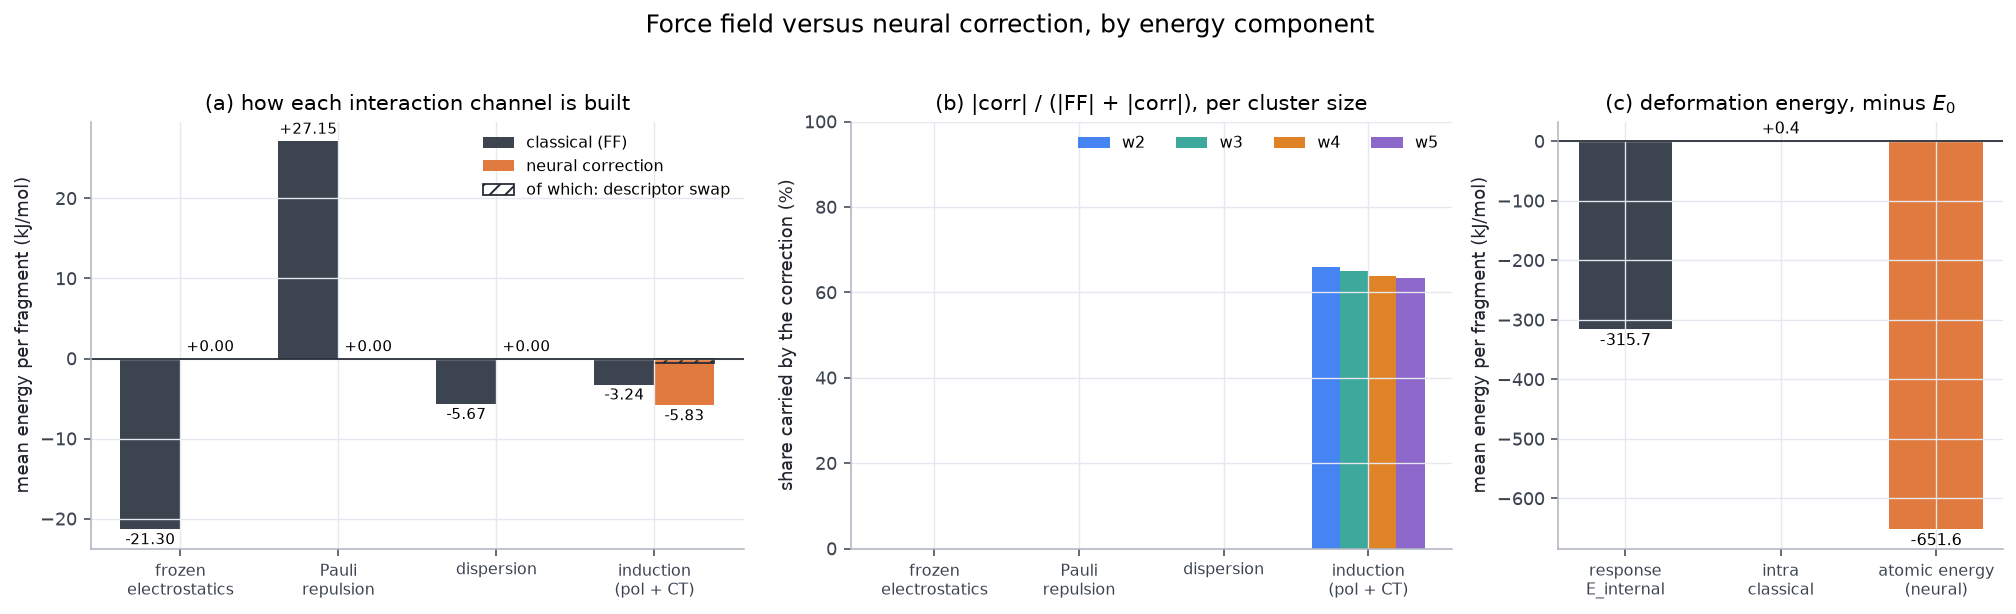

In [ ]:
def plot_ff_vs_correction(split, path=None):
    tags = [t for t in ("w2", "w3", "w4", "w5") if t in set(split["tag"])]
    terms = [(k, l) for k, l in SPLIT_TERMS if f"{k}|ff" in split]
    x = np.arange(len(terms))
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                             gridspec_kw={"width_ratios": [1.25, 1.15, 0.85]})

    ax = axes[0]
    width = 0.38
    ff = [split[f"{k}|ff"].mean() for k, _ in terms]
    corr = [split[f"{k}|corr"].mean() for k, _ in terms]
    ax.bar(x - width / 2, ff, width, color=FF_COLOR, label="classical (FF)")
    ax.bar(x + width / 2, corr, width, color=CORR_COLOR, label="neural correction")
    # Drawn over the correction bar rather than beside it, because it is a *part* of that
    # bar: the share of the correction that the bare descriptor swap already accounts for.
    swap_drawn = False
    for xi, (k, _label) in enumerate(terms):
        if f"{k}|swap" not in split:
            continue
        ax.bar(xi + width / 2, split[f"{k}|swap"].mean(), width, facecolor="none",
               edgecolor="#242934", hatch="///", lw=0.9,
               label=None if swap_drawn else "of which: descriptor swap")
        swap_drawn = True
    for xi, (a, b) in enumerate(zip(ff, corr)):
        for dx, v in ((-width / 2, a), (width / 2, b)):
            ax.annotate(f"{v:+.2f}", (xi + dx, v), ha="center", fontsize=7.5,
                        va="bottom" if v >= 0 else "top",
                        xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    ax.set_title("(a) how each interaction channel is built")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    width = 0.78 / max(1, len(tags))
    for j, tag in enumerate(tags):
        m = split["tag"] == tag
        share = []
        for k, _ in terms:
            a = np.abs(split[f"{k}|ff"][m]).mean()
            b = np.abs(split[f"{k}|corr"][m]).mean()
            share.append(100.0 * b / max(a + b, 1e-30))
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, share, width,
               color=PALETTE.get(tag, "#555"), alpha=0.85, label=tag)
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in terms], fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_ylabel("share carried by the correction (%)")
    ax.set_title("(b) |corr| / (|FF| + |corr|), per cluster size")
    ax.legend(frameon=False, fontsize=8, ncol=len(tags))

    ax = axes[2]
    pieces = [("onebody|internal", "response\nE_internal", FF_COLOR),
              ("onebody|intra_ff", "intra\nclassical", "#7f8794"),
              ("onebody|corr", "atomic energy\n(neural)", CORR_COLOR)]
    values = [split[k].mean() for k, _, _ in pieces]
    ax.bar(np.arange(len(pieces)), values, 0.6, color=[c for _, _, c in pieces])
    for i, v in enumerate(values):
        ax.annotate(f"{v:+.1f}", (i, v), ha="center", fontsize=8,
                    va="bottom" if v >= 0 else "top",
                    xytext=(0, 2 if v >= 0 else -2), textcoords="offset points")
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(np.arange(len(pieces)))
    ax.set_xticklabels([l for _, l, _ in pieces], fontsize=8)
    ax.set_ylabel("mean energy per fragment (kJ/mol)")
    ax.set_title("(c) deformation energy, minus $E_0$")

    fig.suptitle("Force field versus neural correction, by energy component",
                 y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = plot_ff_vs_correction(split, path=FIGDIR / f"{FIGPREFIX}_ff_vs_correction.png")
plt.show()

In [ ]:
def collect_response_properties(model, anchor, device, batch_size=BATCH_SIZE):
    if anchor is None:
        raise ValueError("cfg.data.monomer_path is not set, so no polarizability/multipole anchor is available")
    chunks = {
        "polarizability": {"ref": [], "pred": [], "component": []},
        "dipole": {"ref": [], "pred": [], "component": []},
        "quadrupole": {"ref": [], "pred": [], "component": []},
    }
    tri = np.triu_indices(3)
    alpha_labels = np.array(["xx", "xy", "xz", "yy", "yz", "zz"])
    dip_labels = np.array(["x", "y", "z"])
    quad_labels = alpha_labels

    for start in range(0, len(anchor), batch_size):
        batch = anchor.flat_batch(range(start, min(start + batch_size, len(anchor)))).to(device)
        with torch.no_grad():
            out = model(batch, with_polarizability=True)
        if out.polarizability is not None and batch.polarizability is not None:
            pred_a = to_np(out.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            ref_a = to_np(batch.polarizability)[:, tri[0], tri[1]] / (BOHR_ANG ** 2)
            chunks["polarizability"]["pred"].append(pred_a.ravel())
            chunks["polarizability"]["ref"].append(ref_a.ravel())
            chunks["polarizability"]["component"].extend(np.tile(alpha_labels, pred_a.shape[0]))

        if batch.fragment_dipole is not None and batch.fragment_second_moment is not None:
            quad_c = None if out.quad_s is None else spherical_to_cartesian_quadrupole(out.quad_s)
            frag_q = batch.fragment_charge if batch.fragment_charge is not None else batch.positions.new_zeros(batch.n_fragments)
            pred_d, pred_q = fragment_multipoles(
                out.charges, batch.positions, batch.atomic_numbers, batch.fragment_idx,
                batch.n_fragments, frag_q, out.mu, quad_c,
            )
            ref_d, ref_q = reference_multipoles(
                batch.fragment_dipole, batch.fragment_second_moment, batch.positions,
                batch.atomic_numbers, batch.fragment_idx, batch.n_fragments, frag_q,
            )
            pred_d, ref_d = to_np(pred_d), to_np(ref_d)
            pred_q, ref_q = to_np(pred_q)[:, tri[0], tri[1]], to_np(ref_q)[:, tri[0], tri[1]]
            chunks["dipole"]["pred"].append(pred_d.ravel())
            chunks["dipole"]["ref"].append(ref_d.ravel())
            chunks["dipole"]["component"].extend(np.tile(dip_labels, pred_d.shape[0]))
            chunks["quadrupole"]["pred"].append(pred_q.ravel())
            chunks["quadrupole"]["ref"].append(ref_q.ravel())
            chunks["quadrupole"]["component"].extend(np.tile(quad_labels, pred_q.shape[0]))

    packed = {}
    for key, data in chunks.items():
        if data["pred"]:
            packed[key] = {
                "pred": np.concatenate(data["pred"]),
                "ref": np.concatenate(data["ref"]),
                "component": np.asarray(data["component"]),
            }
    return packed


properties = collect_response_properties(model, anchor, device) if anchor is not None else {}
for key, d in properties.items():
    mae, rmse, r2 = metrics(d["ref"], d["pred"])
    print(f"{key:<16} n={len(d['ref']):<6} MAE={mae:.5g} RMSE={rmse:.5g} R2={r2:.5f}")

polarizability   n=2994   MAE=0.10535 RMSE=0.19144 R2=0.99855
dipole           n=1497   MAE=0.009345 RMSE=0.018485 R2=0.99741
quadrupole       n=2994   MAE=0.036935 RMSE=0.057058 R2=0.99810


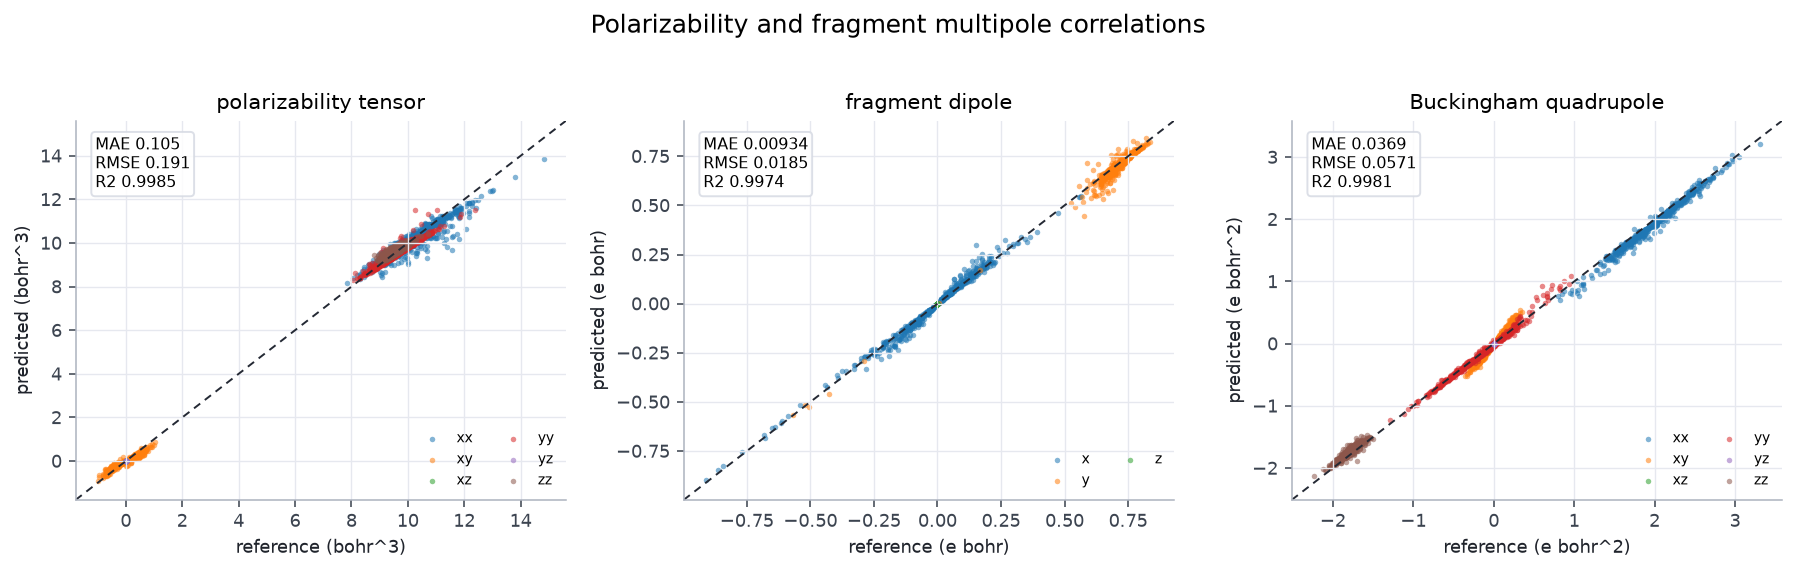

In [ ]:
def plot_property_correlations(properties, path=None):
    labels = {
        "polarizability": ("polarizability tensor", "bohr^3"),
        "dipole": ("fragment dipole", "e bohr"),
        "quadrupole": ("Buckingham quadrupole", "e bohr^2"),
    }
    keys = [k for k in labels if k in properties]
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.9), squeeze=False)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, key in zip(axes.ravel(), keys):
        d = properties[key]
        ref, pred, comp = d["ref"], d["pred"], d["component"]
        lo = min(ref.min(), pred.min())
        hi = max(ref.max(), pred.max())
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
        for i, c in enumerate(sorted(set(comp))):
            m = comp == c
            ax.scatter(ref[m], pred[m], s=8, alpha=0.55, lw=0, color=colors[i % len(colors)], label=c)
        mae, rmse, r2 = metrics(ref, pred)
        ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(labels[key][0])
        ax.set_xlabel(f"reference ({labels[key][1]})")
        ax.set_ylabel(f"predicted ({labels[key][1]})")
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.suptitle("Polarizability and fragment multipole correlations", y=1.03, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

if properties:
    fig = plot_property_correlations(properties, path=FIGDIR / f"{FIGPREFIX}_response_property_correlations.png")
    plt.show()

In [ ]:
def feature_streams(model, batch):
    frag = batch.fragment_idx
    if model.environment is None:
        h_frag = h_env = model._augment(model.featurizer(batch, frag), batch, frag)
    else:
        grouped, full = model.featurizer(batch, frag, also_ungrouped=True)
        h_frag = model._augment(grouped, batch, frag)
        h_env = model.environment(h_frag, model._augment(full, batch, frag))
    return h_frag, h_env


def collect_atom_parameters(model, datasets, device, n_frames=PARAMETER_FRAMES_PER_CLUSTER, batch_size=BATCH_SIZE):
    parts = {k: [] for k in [
        "tag", "Z", "q", "chi", "eta", "z_pen", "b_pen", "cquad", "env_norm",
        "c6", "b_disp", "q_pauli", "b_pauli", "mu_pauli", "quad_pauli",
        "r0_elst", "r0_pauli", "r0_disp",
    ]}
    scalars = {}
    for tag, ds in datasets.items():
        take = min(n_frames, len(ds))
        for start in range(0, take, batch_size):
            batch = ds.flat_batch(range(start, min(start + batch_size, take))).to(device)
            with torch.no_grad():
                out = model(batch)
                h_frag, h_env = feature_streams(model, batch)
                c6, b_disp = model.disp_params(h_env.inv_feats, h_env.species_idx)
                q_p, b_p, mu_p, quad_p = model.pauli_params(
                    h_env.inv_feats, h_env.species_idx, h_env.vec_feats, h_env.equiv_feats
                )
                r0, alpha = model.range_heads(h_env.inv_feats, h_env.species_idx)
            n = len(batch.atomic_numbers)
            parts["tag"].extend([tag] * n)
            parts["Z"].append(to_np(batch.atomic_numbers))
            parts["q"].append(to_np(out.response.charges))
            parts["chi"].append(to_np(out.response.chi))
            parts["eta"].append(to_np(out.response.eta))
            parts["z_pen"].append(to_np(out.response.z))
            parts["b_pen"].append(to_np(out.response.b))
            cquad = out.response.cquad
            if cquad is not None and cquad.dim() > 1:
                cquad = cquad.reshape(cquad.shape[0], -1).norm(dim=-1)
            parts["cquad"].append(to_np(cquad) if cquad is not None else np.zeros(n))
            parts["env_norm"].append(to_np(out.environment_norm) if out.environment_norm is not None else np.zeros(n))
            parts["c6"].append(to_np(c6))
            parts["b_disp"].append(to_np(b_disp))
            parts["q_pauli"].append(to_np(q_p))
            parts["b_pauli"].append(to_np(b_p))
            parts["mu_pauli"].append(to_np(mu_p.norm(dim=-1)) if mu_p is not None else np.zeros(n))
            parts["quad_pauli"].append(to_np(quad_p.norm(dim=-1)) if quad_p is not None else np.zeros(n))
            for key in ("elst", "pauli", "disp"):
                parts[f"r0_{key}"].append(to_np(r0[key]))
                scalars[f"alpha_{key}"] = float(to_np(alpha[key]))
    packed = {}
    for k, values in parts.items():
        if k == "tag":
            packed[k] = np.asarray(values)
        else:
            packed[k] = np.concatenate(values)
    packed.update(scalars)
    return packed


params = collect_atom_parameters(model, datasets, device)
print(f"parameter atoms: {len(params['Z'])}")
for key in ("alpha_elst", "alpha_pauli", "alpha_disp"):
    print(f"{key}: {params[key]:.4g} 1/A")

parameter atoms: 5040
alpha_elst: 37.35 1/A
alpha_pauli: 37.33 1/A
alpha_disp: 37.33 1/A


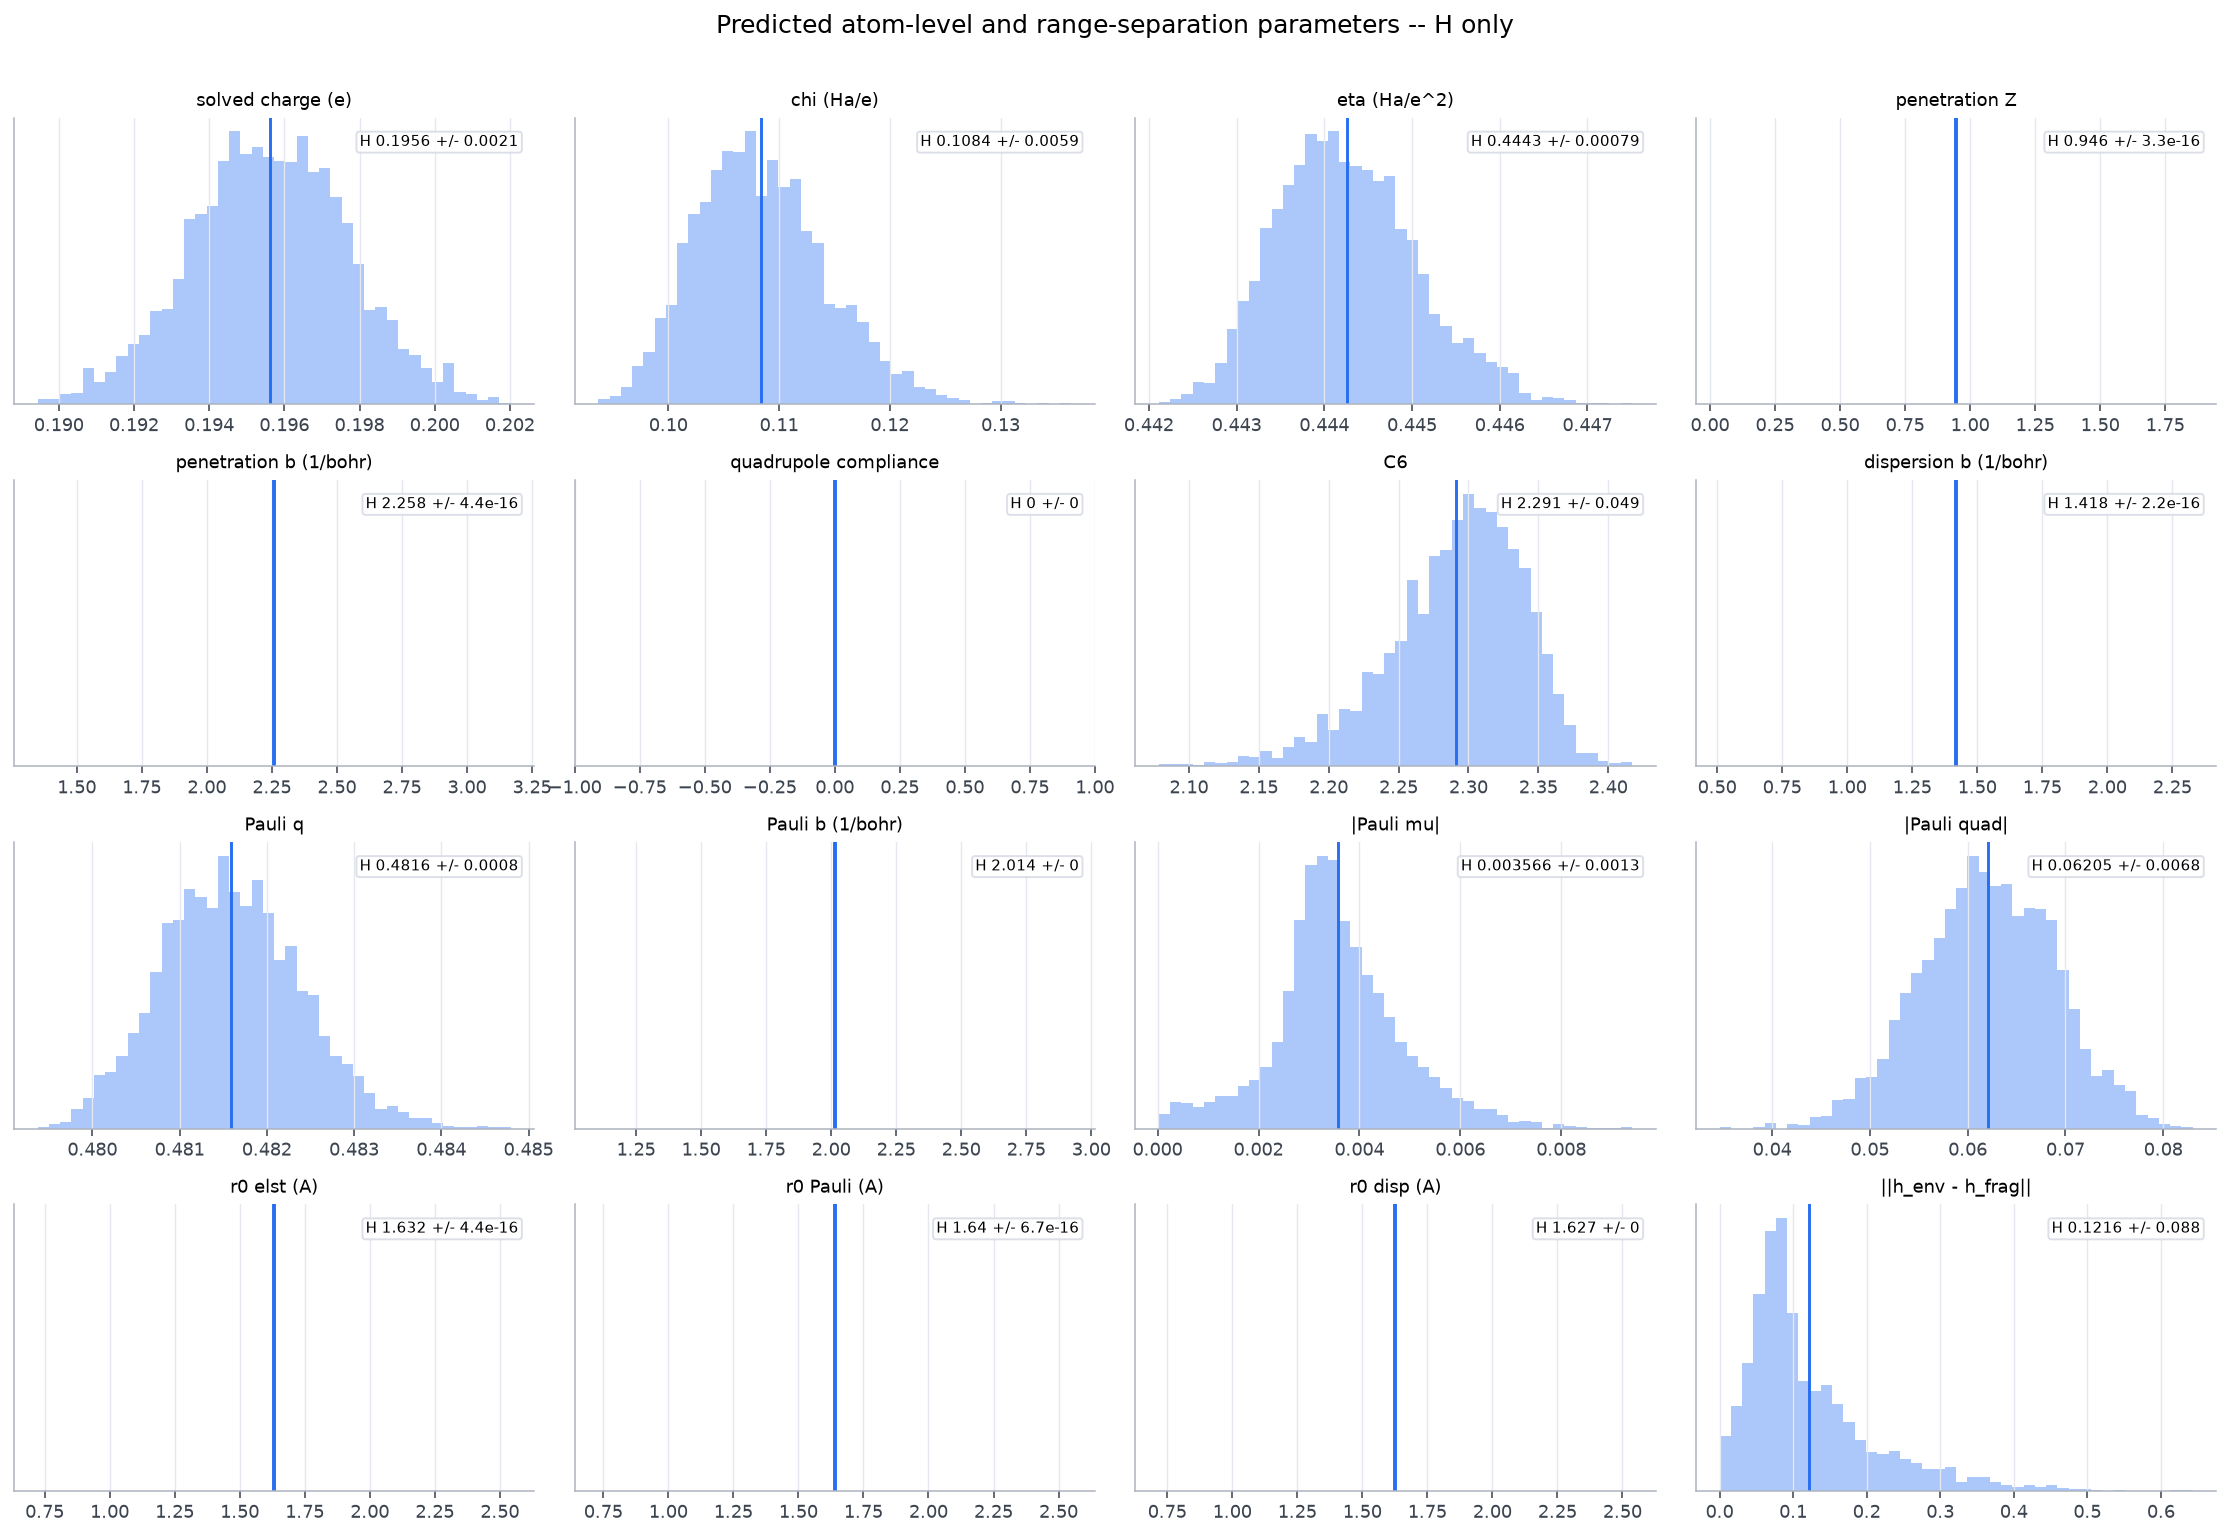

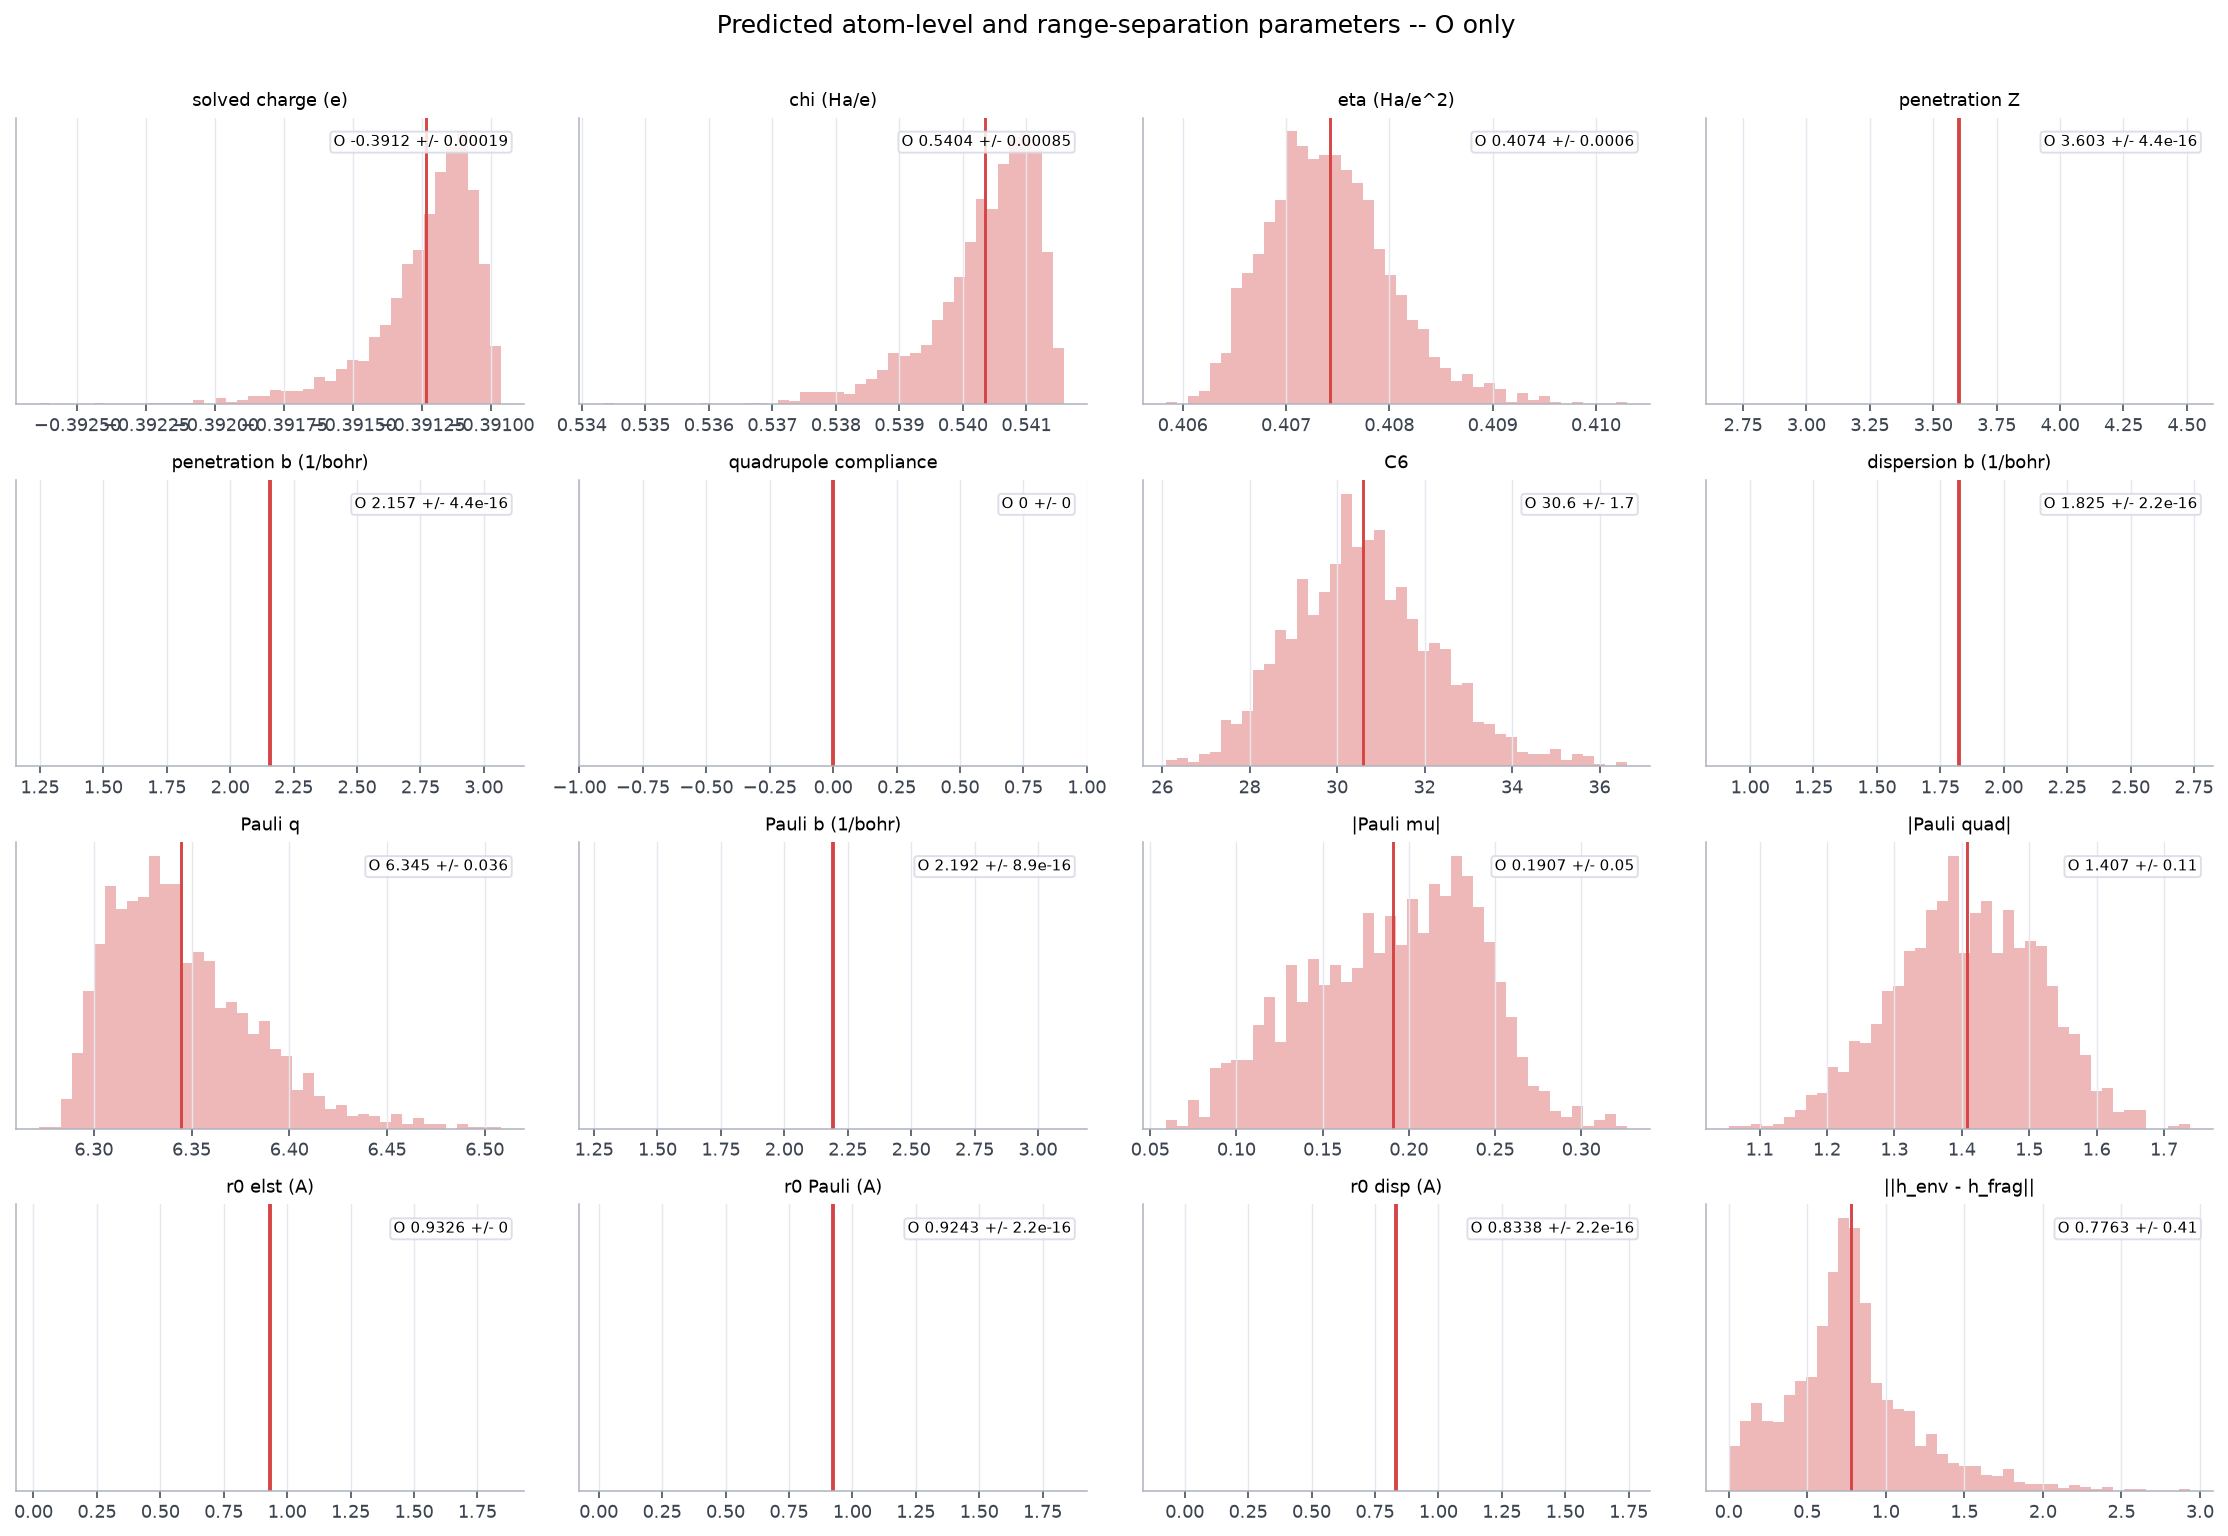

In [ ]:
PARAM_SPECS = [
    ("q", "solved charge (e)"),
    ("chi", "chi (Ha/e)"),
    ("eta", "eta (Ha/e^2)"),
    ("z_pen", "penetration Z"),
    ("b_pen", "penetration b (1/bohr)"),
    ("cquad", "quadrupole compliance"),
    ("c6", "C6"),
    ("b_disp", "dispersion b (1/bohr)"),
    ("q_pauli", "Pauli q"),
    ("b_pauli", "Pauli b (1/bohr)"),
    ("mu_pauli", "|Pauli mu|"),
    ("quad_pauli", "|Pauli quad|"),
    ("r0_elst", "r0 elst (A)"),
    ("r0_pauli", "r0 Pauli (A)"),
    ("r0_disp", "r0 disp (A)"),
    ("env_norm", "||h_env - h_frag||"),
]


def plot_parameter_distributions(params, z=None, path=None, ncols=4):
    """One panel per parameter; `z` restricts to a single element.

    Split by element because the two are not on the same scale -- C6 is 2.1 on H and 37 on O,
    so a shared axis draws H as a spike at the origin and hides its whole distribution. One
    figure per element lets each axis autoscale to what it is showing.
    """
    mask = np.ones(len(params["Z"]), bool) if z is None else (params["Z"] == z)
    zs = sorted(set(params["Z"][mask]))
    nrows = int(np.ceil(len(PARAM_SPECS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.7 * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, (key, label) in zip(axes.ravel(), PARAM_SPECS):
        ax.set_visible(True)
        for zi in zs:
            vals = params[key][mask & (params["Z"] == zi)]
            if len(vals) == 0:
                continue
            color = ELEMENT_COLOR.get(int(zi), "#555")
            name = ELEMENT.get(int(zi), str(zi))
            if float(vals.max() - vals.min()) <= 1e-12:
                # A per-element constant -- every `r0` while `environment_r0` is off, and any
                # head whose `environment_*` switch is false. A histogram of one value is a
                # single bin of meaningless height, so draw the value instead. Seeing which
                # panels are lines rather than distributions is itself the readout.
                ax.axvline(float(vals[0]), color=color, lw=2.0, label=name)
                ax.set_xlim(float(vals[0]) - 1.0, float(vals[0]) + 1.0)
            else:
                ax.hist(vals, bins=42, density=True, histtype="stepfilled", alpha=0.38,
                        color=color, label=name)
                ax.axvline(vals.mean(), color=color, lw=1.5)
        summary = "\n".join(
            f"{ELEMENT.get(int(zi), zi)} {params[key][mask & (params['Z'] == zi)].mean():.4g}"
            f" +/- {params[key][mask & (params['Z'] == zi)].std():.2g}" for zi in zs
        )
        ax.text(0.97, 0.94, summary, transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
                bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
        ax.set_title(label, fontsize=9)
        ax.set_yticks([])
    if z is None:
        axes.ravel()[0].legend(frameon=False, fontsize=8)
    who = "all elements" if z is None else f"{ELEMENT.get(int(z), z)} only"
    fig.suptitle(f"Predicted atom-level and range-separation parameters -- {who}",
                 y=1.01, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


for z in sorted(set(params["Z"])):
    name = ELEMENT.get(int(z), str(int(z)))
    fig = plot_parameter_distributions(
        params, z=int(z),
        path=FIGDIR / f"{FIGPREFIX}_parameter_distributions_{name}.png",
    )
    plt.show()

In [ ]:
class EnergyTermModel(torch.nn.Module):
    def __init__(self, model, term):
        super().__init__()
        self.model = model
        self.term = term

    def forward(self, batch):
        out = self.model(batch)
        if self.term == "total":
            # For the MBE plot, the total binding contribution beyond pairwise is the
            # interaction sum. One-body deformation cancels only if singleton terms are
            # included; this helper's convention is E(singleton) = 0.
            energy = out.energy.new_zeros(out.energy.shape)
            for value in out.interaction.values():
                energy = energy + value
        elif self.term == "onebody":
            energy = pool_fragments_to_frames(out.fragment_energy, batch)
        else:
            energy = out.interaction[self.term]
        return SimpleNamespace(energy=energy)


def strongest_indices(dataset, n, key=MBE_SORT_KEY):
    batch = dataset.flat_batch(range(len(dataset)))
    if batch.eda is not None and key in batch.eda:
        values = to_np(batch.eda[key])
    else:
        values = to_np(batch.energy)
    return np.argsort(values)[:min(n, len(values))].tolist()


def collect_many_body_by_term(model, datasets, terms=None, per_cluster=MBE_PER_CLUSTER):
    if terms is None:
        terms = ["elst", "pauli", "disp"]
        if model.induction:
            terms.append("induction")
        terms.append("total")
    rows = []
    for term in terms:
        if term != "total" and term not in model.pair_head.channels and term not in ("induction", "onebody"):
            continue
        wrapped = EnergyTermModel(model, term).to(next(model.parameters()).device)
        for tag in [t for t in ("w3", "w4", "w5") if t in datasets]:
            ds = datasets[tag]
            idx = strongest_indices(ds, per_cluster)
            res = mbe_dataset(wrapped, ds, idx, split_components=False, progress_every=0)
            k = KJMOL_PER_HARTREE
            for i in range(len(idx)):
                row = {
                    "term": term,
                    "tag": tag,
                    "n_fragments": int(res.n_fragments[i]),
                    "total": float(res.total[i]) * k,
                    "two_body": float(res.two_body[i]) * k,
                    "many_body": float(res.many_body[i]) * k,
                }
                for order in (3, 4, 5):
                    vals = res.by_order.get(order)
                    row[f"e{order}"] = float(vals[i]) * k if vals is not None else 0.0
                rows.append(row)
    return rows


mbe_rows = collect_many_body_by_term(model, datasets)
print(f"many-body rows: {len(mbe_rows)}")
for term in sorted({r['term'] for r in mbe_rows}):
    vals = np.array([r["many_body"] for r in mbe_rows if r["term"] == term])
    print(f"{term:<8} mean={vals.mean():>9.4f} kJ/mol   mean abs={np.abs(vals).mean():>9.4f}")

many-body rows: 600
disp     mean=  -0.1229 kJ/mol   mean abs=   0.2838
elst     mean=   0.0000 kJ/mol   mean abs=   0.0000
induction mean= -11.1055 kJ/mol   mean abs=  11.1055
pauli    mean=  -0.3530 kJ/mol   mean abs=   0.5350
total    mean= -11.5814 kJ/mol   mean abs=  11.5814


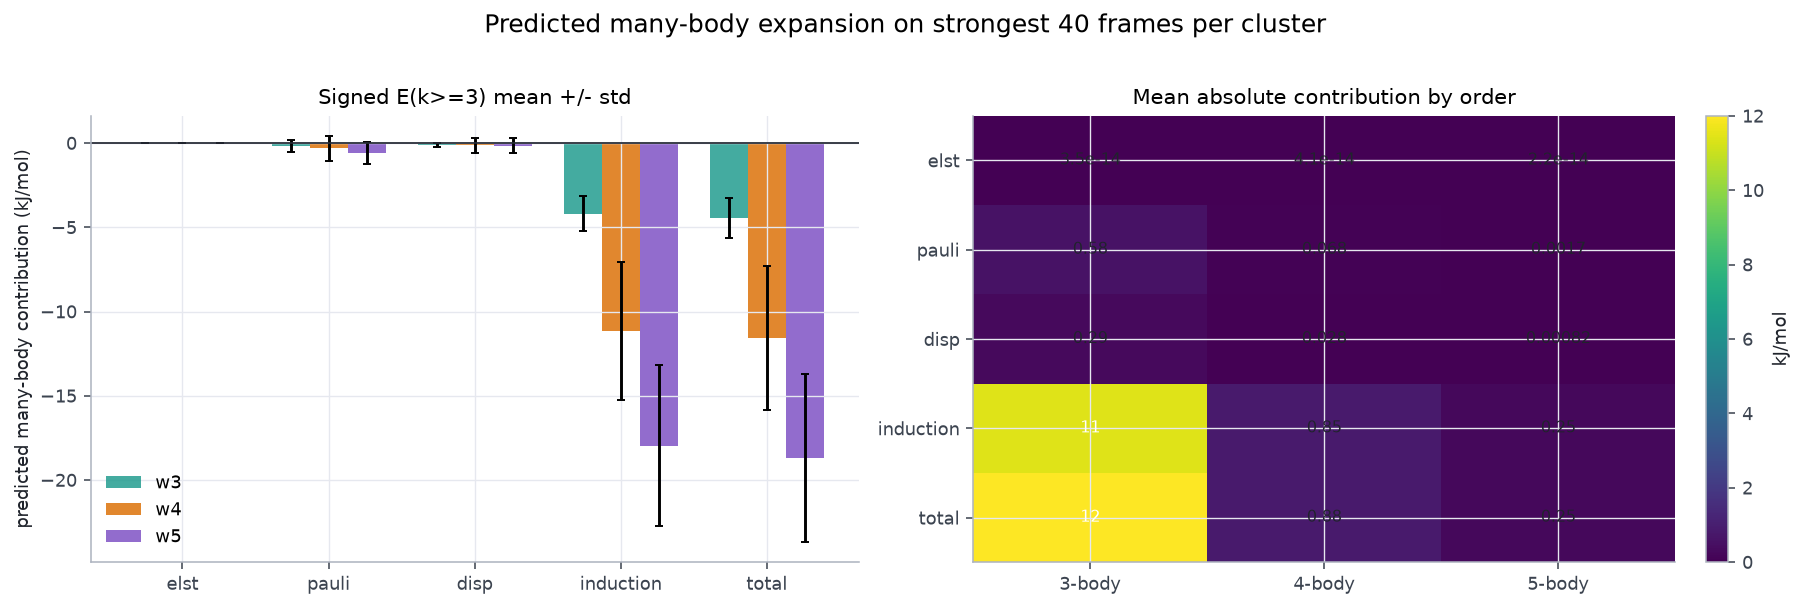

In [ ]:
def plot_many_body(rows, path=None):
    terms = [t for t in ["elst", "pauli", "disp", "induction", "total"] if any(r["term"] == t for r in rows)]
    tags = [t for t in ["w3", "w4", "w5"] if any(r["tag"] == t for r in rows)]
    x = np.arange(len(terms))
    width = 0.78 / max(1, len(tags))
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2))

    ax = axes[0]
    for j, tag in enumerate(tags):
        means, stds = [], []
        for term in terms:
            vals = np.array([r["many_body"] for r in rows if r["term"] == term and r["tag"] == tag])
            means.append(np.mean(vals) if len(vals) else 0.0)
            stds.append(np.std(vals) if len(vals) else 0.0)
        ax.bar(x + (j - (len(tags) - 1) / 2) * width, means, width=width,
               yerr=stds, capsize=2, color=PALETTE.get(tag, "#555"), alpha=0.82, label=tag)
    ax.axhline(0.0, color="#242934", lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(terms)
    ax.set_ylabel("predicted many-body contribution (kJ/mol)")
    ax.set_title("Signed E(k>=3) mean +/- std")
    ax.legend(frameon=False)

    ax = axes[1]
    orders = ["e3", "e4", "e5"]
    image = np.zeros((len(terms), len(orders)))
    for i, term in enumerate(terms):
        for j, order in enumerate(orders):
            vals = np.array([r[order] for r in rows if r["term"] == term])
            image[i, j] = np.mean(np.abs(vals)) if len(vals) else 0.0
    im = ax.imshow(image, aspect="auto", cmap="viridis")
    ax.set_yticks(np.arange(len(terms)))
    ax.set_yticklabels(terms)
    ax.set_xticks(np.arange(len(orders)))
    ax.set_xticklabels(["3-body", "4-body", "5-body"])
    ax.set_title("Mean absolute contribution by order")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("kJ/mol")
    for i in range(len(terms)):
        for j in range(len(orders)):
            ax.text(j, i, f"{image[i, j]:.2g}", ha="center", va="center",
                    color="white" if image[i, j] > image.max() * 0.45 else "#20242c", fontsize=8)

    fig.suptitle(f"Predicted many-body expansion on strongest {MBE_PER_CLUSTER} frames per cluster", y=1.02, fontsize=13)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_many_body(mbe_rows, path=FIGDIR / f"{FIGPREFIX}_many_body_by_term.png")
plt.show()

In [ ]:
def collect_force_predictions(model, datasets, cfg, device, n_frames=FORCE_FRAMES_PER_CLUSTER):
    ref_parts, pred_parts, tags = [], [], []
    for tag, ds in datasets.items():
        if not ds.has_forces:
            print(f"{tag}: no force labels; skipping")
            continue
        indices = frame_indices(ds, cfg)[:min(n_frames, len(ds))]
        for idx in indices:
            batch = ds.flat_batch([idx]).to(device)
            batch.positions.requires_grad_(True)
            out = model(batch)
            forces = compute_forces(out.energy, batch.positions, create_graph=False)
            ref = to_np(batch.forces) * KJMOL_PER_HARTREE
            pred = to_np(forces) * KJMOL_PER_HARTREE
            ref_parts.append(ref.reshape(-1))
            pred_parts.append(pred.reshape(-1))
            tags.extend([tag] * ref.size)
    return {
        "ref": np.concatenate(ref_parts),
        "pred": np.concatenate(pred_parts),
        "tag": np.asarray(tags),
    }


forces = collect_force_predictions(model, datasets, cfg, device)
mae, rmse, r2 = metrics(forces["ref"], forces["pred"])
print(f"force components: n={len(forces['ref'])}  MAE={mae:.5g}  RMSE={rmse:.5g}  R2={r2:.5f}  unit=kJ/mol/A")

force components: n=5040  MAE=4.9556  RMSE=7.1082  R2=0.99138  unit=kJ/mol/A


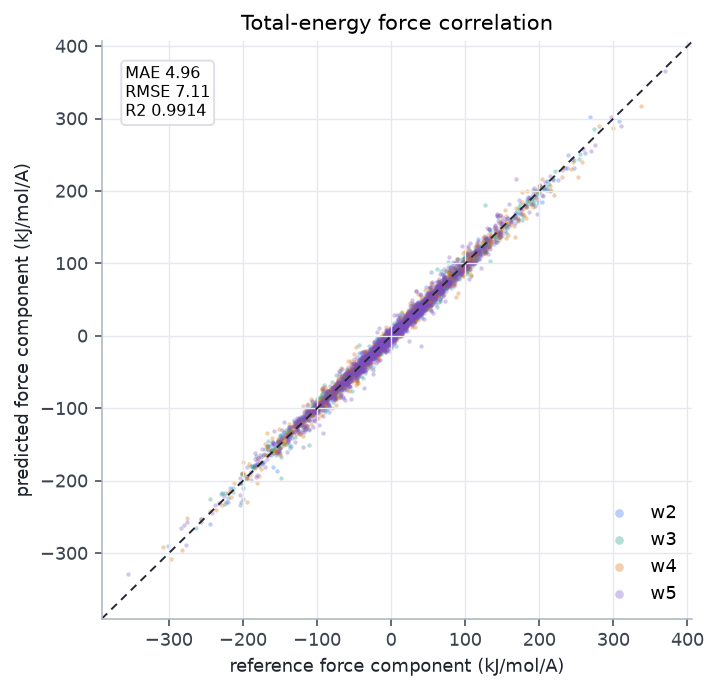

In [ ]:
def plot_force_correlation(forces, path=None):
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    ref, pred, tags = forces["ref"], forces["pred"], forces["tag"]
    lo = min(ref.min(), pred.min())
    hi = max(ref.max(), pred.max())
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#242934", lw=1, ls=(0, (4, 3)))
    for tag in sorted(set(tags)):
        m = tags == tag
        ax.scatter(ref[m], pred[m], s=5, alpha=0.32, lw=0, color=PALETTE.get(tag, "#555"), label=tag)
    mae, rmse, r2 = metrics(ref, pred)
    ax.text(0.04, 0.96, f"MAE {mae:.3g}\nRMSE {rmse:.3g}\nR2 {r2:.4f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#d6dae3", "alpha": 0.85})
    ax.set_xlabel("reference force component (kJ/mol/A)")
    ax.set_ylabel("predicted force component (kJ/mol/A)")
    ax.set_title("Total-energy force correlation")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.legend(frameon=False, markerscale=2)
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig

fig = plot_force_correlation(forces, path=FIGDIR / f"{FIGPREFIX}_force_correlation.png")
plt.show()

## Notes

- To regenerate the same diagnostics for a different model, edit `CHECKPOINT` at the top. If
  the checkpoint lives in a staged run directory such as `water_staged_frozen`, `STAGE =
  "auto"` applies the matching stage overrides from `CONFIG`. Figure names follow that
  directory, so the two stages do not overwrite each other's output.
- `induction` is one channel fitted against `eda_pol + eda_ct`. On a `frozen`-stage checkpoint
  the model has no such channel, so its panels drop out of the correlation, split, and
  many-body figures rather than erroring.
- The induction split reports a third number, `swap`: how much of the neural correction is the
  `h_frag -> h_env` descriptor change alone, at the same relaxed state. It needs no charge to
  move and no multipole to relax, so a large `swap/corr` means the channel is being fitted
  through the feature stream rather than through the coupled solve. Read it together with the
  classical half -- if `ind_ff` is small and `swap` is most of `ind_corr`, induction has become
  a network wearing the label.
- Monomer deformation and cluster binding energies use `REFERENCE_SPECIES` from
  `ISOLATED_SPECIES_REFERENCE` as the zero of energy. The same constant is subtracted from the
  prediction and the reference, so it cancels: an offset in those panels is the model's, not
  the reference's.
- The deformation and binding panels pool fragments to frames, which multiplies a per-fragment
  constant by `n_fragments`. That is why a constant one-body bias is drawn as a size-dependent
  offset -- see the one-body residual section, which reports the constant on its own.
- The classical/neural split is per fragment so the cluster sizes are comparable. `E_0` is
  excluded from the one-body panel: it is a fixed atomic reference, neither fitted nor a
  correction.
- Parameter distributions are split by element. H and O differ by more than an order of
  magnitude on several parameters (C6, chi), so a shared axis hides one of them.
- The many-body expansion can be expensive because each frame is evaluated over all fragment
  subsets. Increase `MBE_PER_CLUSTER` for final figures and decrease it while iterating.
- Force correlations use total-energy gradients and are intentionally sampled by
  `FORCE_FRAMES_PER_CLUSTER`.
